In [1]:
import numpy as np
import matplotlib.pyplot as plt

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6 * ( ( y[i+1]-y[i] )/h[i] - ( y[i]-y[i-1] )/h[i-1]) # Right-hand side vector
        
    return A, B, C, D

In [2]:
def thomas_algorithm(a, b, c, d):
    
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (lengt h n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """

    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
    # Back substitution
    M = np.zeros(n)
    M[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        M[i] = (d[i] - c[i] * M[i+1]) / b[i]
    return M

In [3]:
x = np.array([0, 2, 5, 7, 8])
y = np.array([1, 8, 4, 2, 3])

x_eval = np.linspace(np.min(x), np.max(x), 1000)

A, B, C, D = setup_tridiagonal_matrix(x, y)
M_out = thomas_algorithm(A, B, C, D)
M = np.zeros(len(x))
M[1:-1] = M_out

In [4]:
def evaluate_spline(x_interp, x_data, y_data, M):
    h = np.diff(x_data)
    y_eval = [] #starts out as normal array for efficiency
    
    for val in x_interp:
        i = len(x_data) - 2
        for j in range(len(x_data) - 1):
            if x_data[j] <= val < x_data[j+1]: i = j
        
        dx_left = x_data[i+1] - val
        dx_right = val - x_data[i]
        
        # Cubic Spline Formula
        term1 = (M[i] * (dx_left**3)) / (6 * h[i])
        term2 = (M[i+1] * (dx_right**3)) / (6 * h[i])
        term3 = (y_data[i] - (M[i] * h[i]**2 / 6)) * (dx_left / h[i])
        term4 = (y_data[i+1] - (M[i+1] * h[i]**2 / 6)) * (dx_right / h[i])
        
        y_eval.append(term1 + term2 + term3 + term4)
        
    return np.array(y_eval)

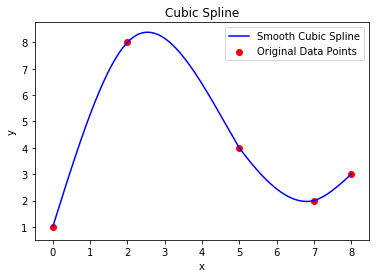

In [5]:
x_interp = np.linspace(x.min(), x.max(), 1000)
y_interp = evaluate_spline(x_interp, x, y, M)

plt.figure()
plt.plot(x_interp, y_interp, label='Smooth Cubic Spline', color='blue')
plt.scatter(x, y, color='red', label='Original Data Points')

plt.title('Cubic Spline')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()